# GitHub Delivery Overview

Rendered overview with embedded figure previews and per-project output manifests. This notebook reads existing files only — no recomputation.

**Projects:**
- `exp1_alignment_transfer` — Controlled Alignment and Regret Transfer
- `exp2_real_delayed_conversion_logs` — Real Delayed Conversion Logs
- `exp3_sequential_recommendation_delayed_feedback` — Sequential Recommendation with Delayed Feedback
- `exp4_controlled_route_audit` — Controlled Route Alignment and Evidence-Qualified Audit
- `toy` — Toy examples and exploratory analysis

In [4]:

from pathlib import Path
import pandas as pd
from IPython.display import display, Markdown, Image

ROOT = Path('..').resolve()
PROJECTS = [
    ('exp1_alignment_transfer', None),
    ('exp2_real_delayed_conversion_logs', None),
    ('exp3_sequential_recommendation_delayed_feedback', None),
    ('exp4_controlled_route_audit', None),
    ('toy', 'ipy/toy_result_check.ipynb'),
]

def count_files(base, patterns):
    total = 0
    for pattern in patterns:
        total += len([p for p in base.glob(pattern) if p.is_file()])
    return total

def prefer_figures(base):
    paths = sorted(base.glob('outputs/**/figures/**/*.png'))
    def score(path):
        s = path.as_posix().lower()
        value = 0
        if '/outputs/full/' in s or '/full_' in s or 'exp4_full' in s:
            value -= 100
        if '/outputs/fast/' in s or '/fast_' in s or 'fast_pipeline' in s:
            value -= 50
        if 'code_check_smoke' in s:
            value += 200
        return (value, s)
    return sorted(paths, key=score)

rows = []
for name, nb_path in PROJECTS:
    base = ROOT / name
    nb_exists = nb_path is not None and (base / nb_path).exists()
    rows.append({
        'project': name,
        'README': (base/'README.md').exists(),
        'notebook': nb_exists,
        'outputs': (base/'outputs').exists(),
        'tables': count_files(base, ['outputs/**/tables/*.csv']),
        'summaries': count_files(base, ['outputs/**/summaries/*.csv','outputs/**/summary/*.csv']),
        'figures_png': count_files(base, ['outputs/**/figures/**/*.png']),
        'runlogs': (base/'runlogs').exists() if (base/'runlogs').exists() else False,
    })
df = pd.DataFrame(rows)
display(df)


,project,README,notebook,outputs,tables,summaries,figures_png,runlogs
0,exp1_alignment_transfer,True,False,True,3,0,11,False
1,exp2_real_delayed_conversion_logs,True,False,True,9,0,9,False
2,exp3_sequential_recommendation_delayed_feedback,True,False,True,22,0,8,False
3,exp4_controlled_route_audit,True,False,True,14,0,12,False
4,toy,True,True,True,0,6,4,False


### exp1_alignment_transfer

`exp1_alignment_transfer/outputs/full/figures/png/fig_exp1_alignment_transfer.png`

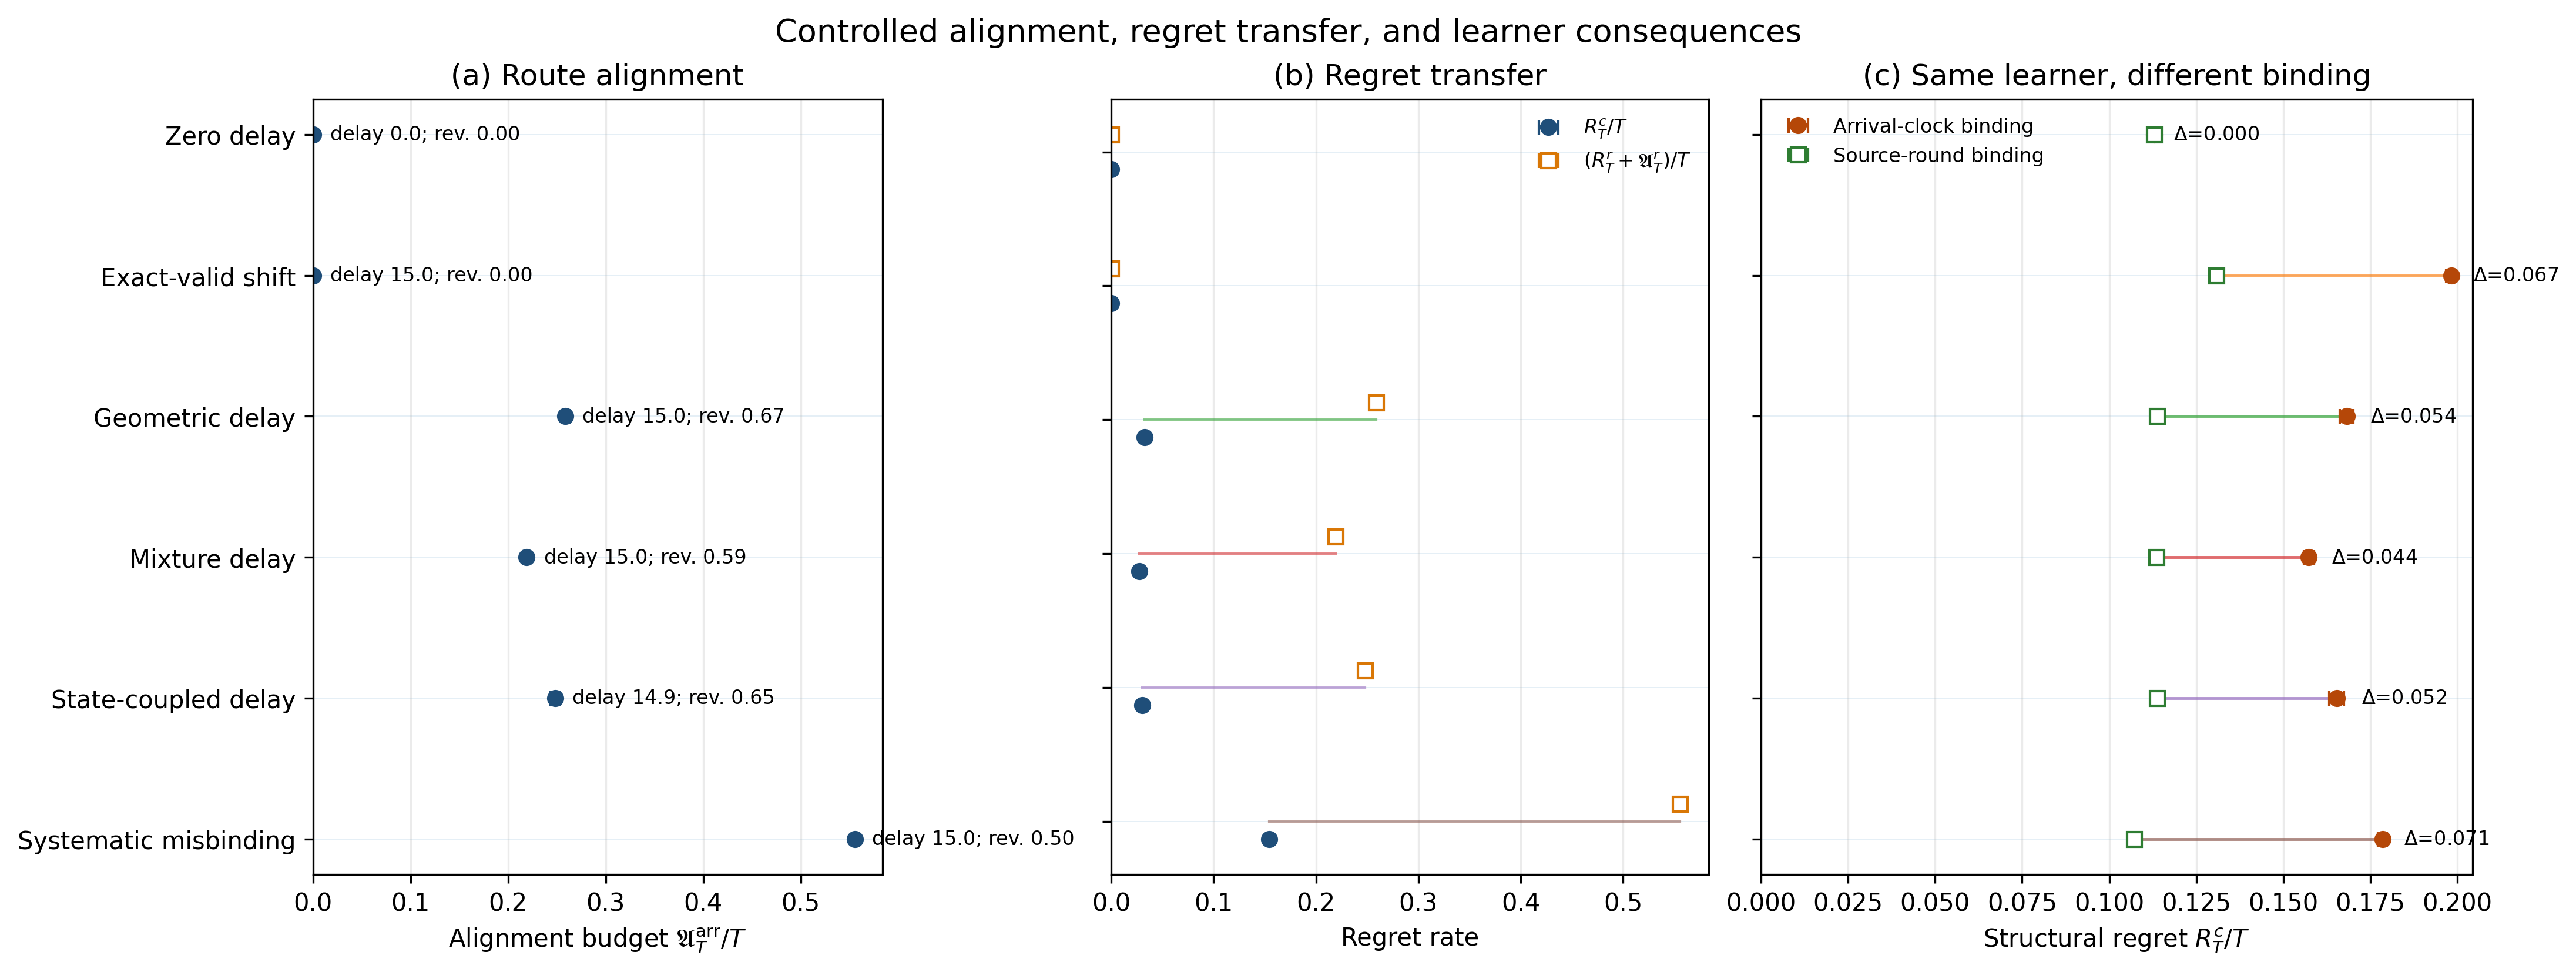

### exp2_real_delayed_conversion_logs

`exp2_real_delayed_conversion_logs/outputs/exp2-fast-20260727T100101+0800/figures/figure_exp2_delay_appendix.png`

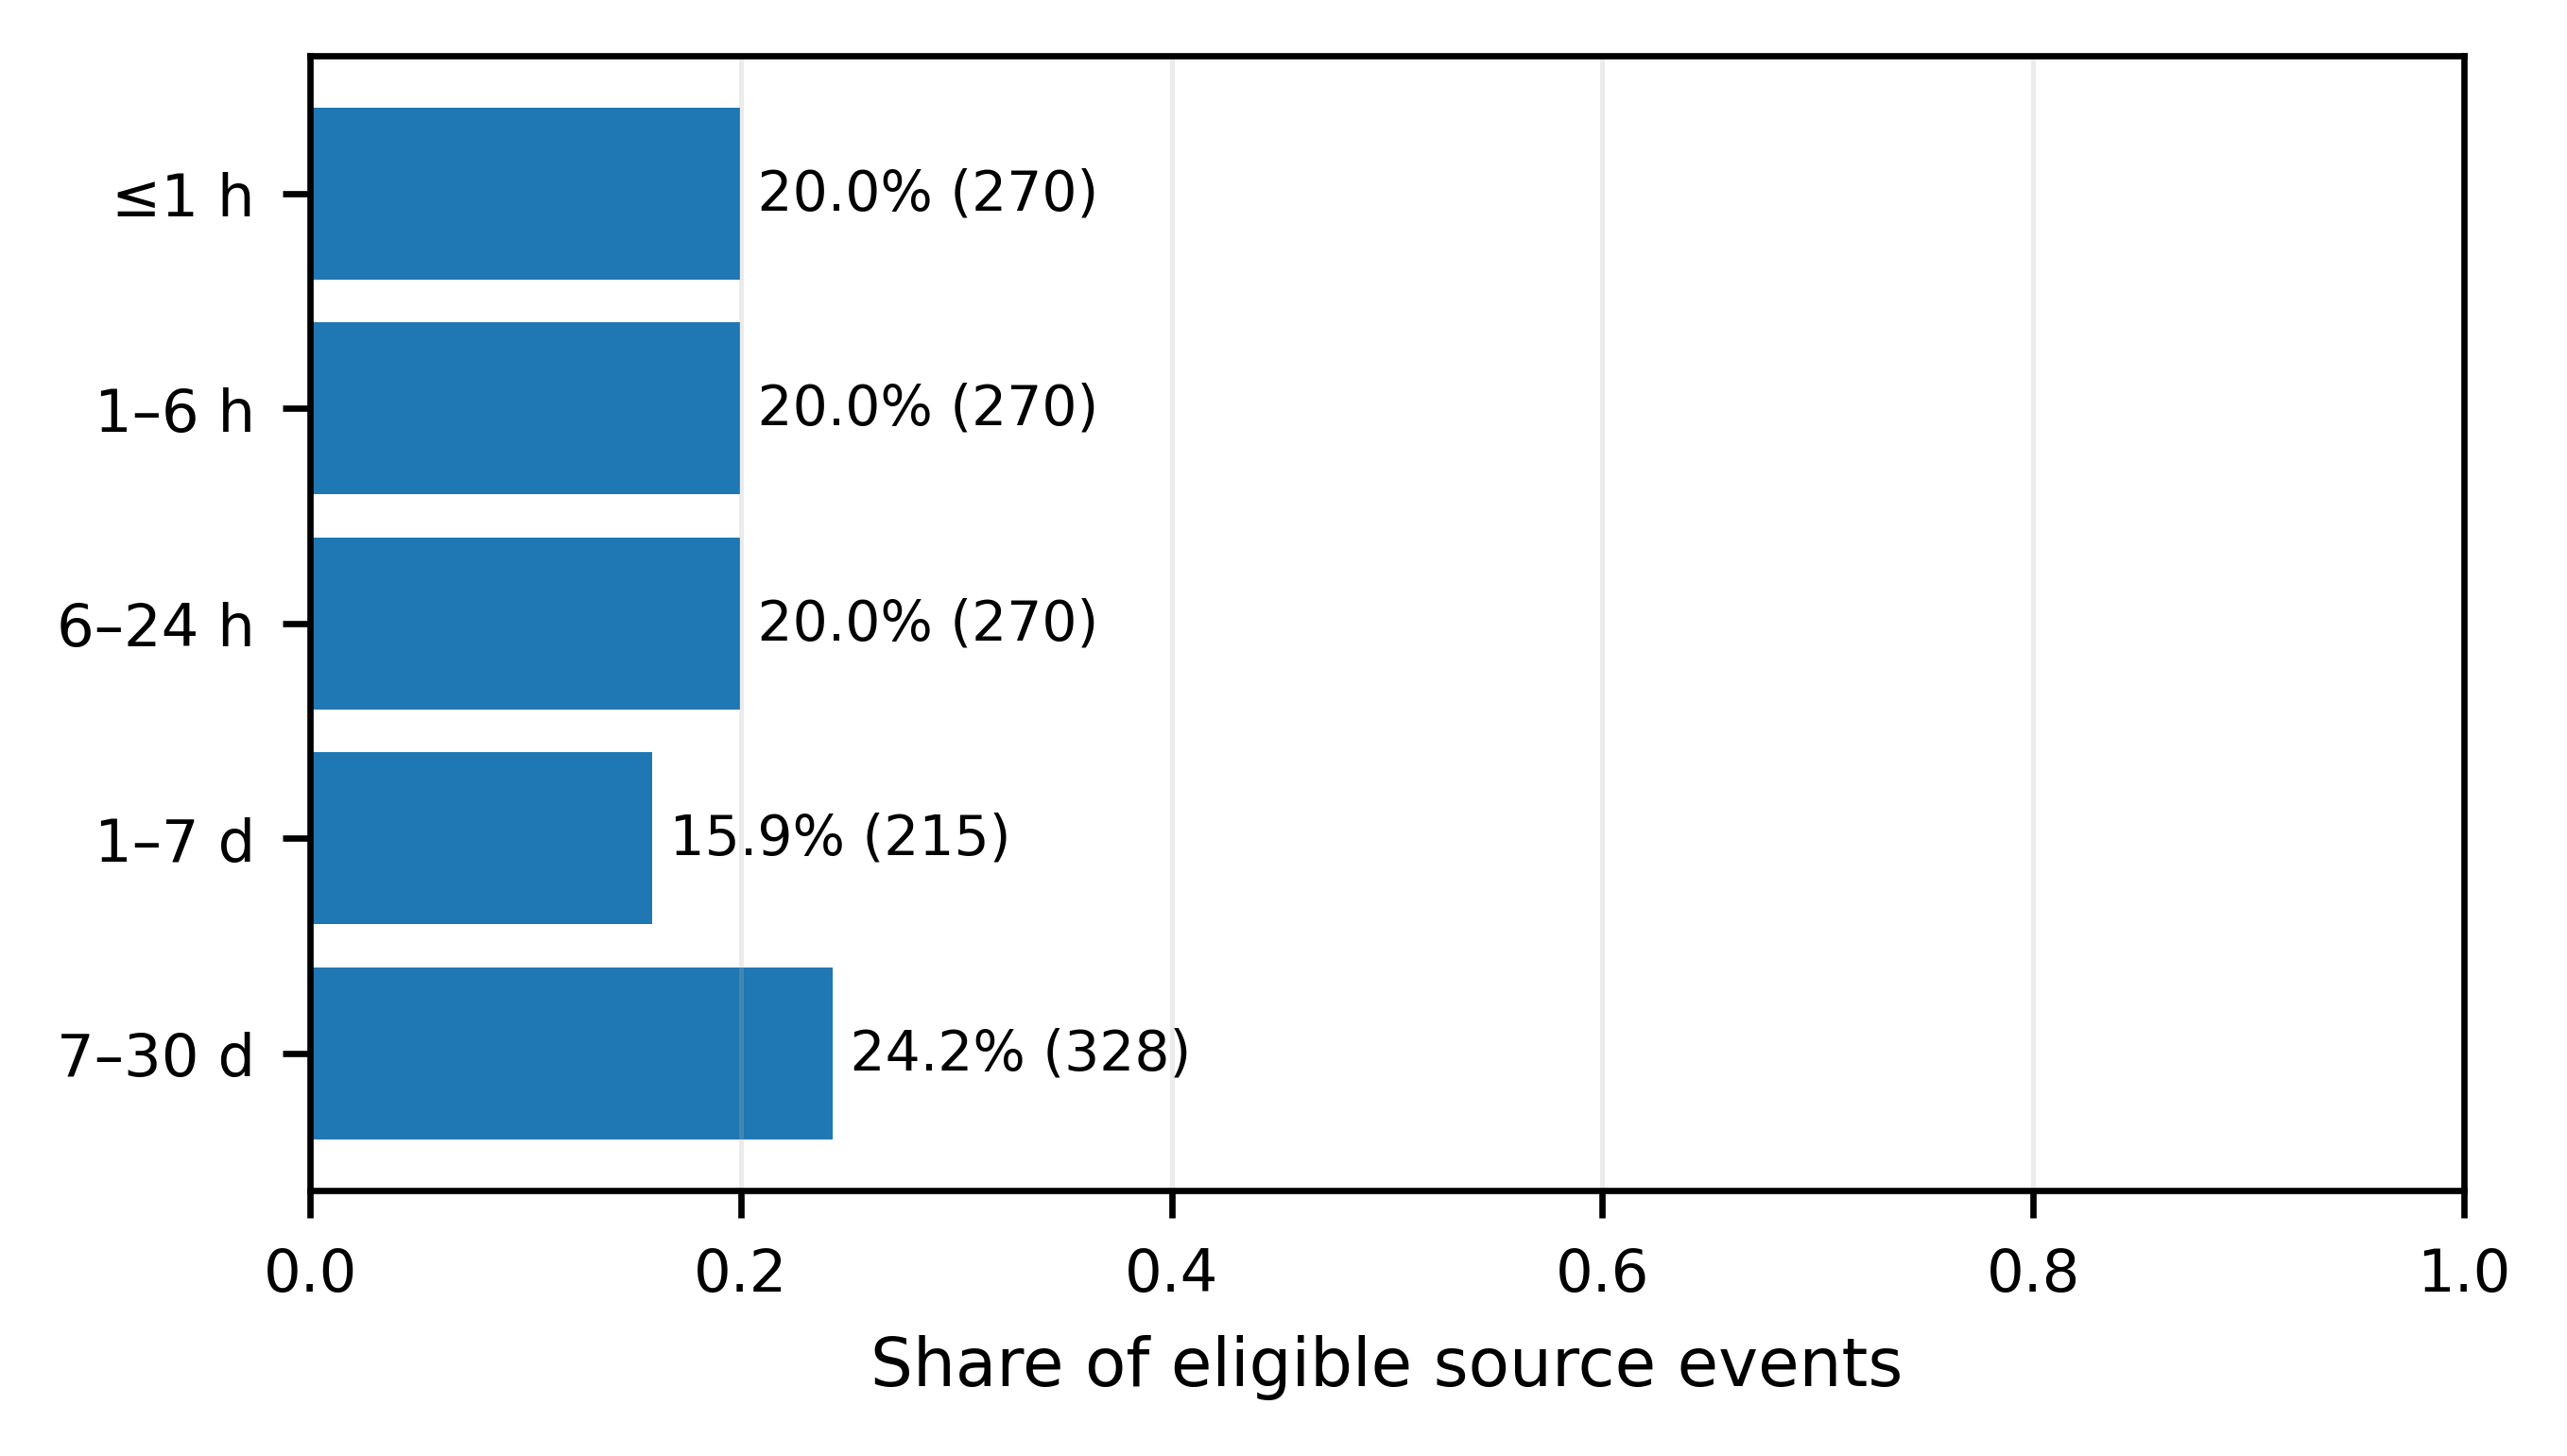

### exp3_sequential_recommendation_delayed_feedback

`exp3_sequential_recommendation_delayed_feedback/outputs/exp3-fast-20260727T113235Z/figures/appendix/exp3_appendix_arrival_carrier_diagnostic.png`

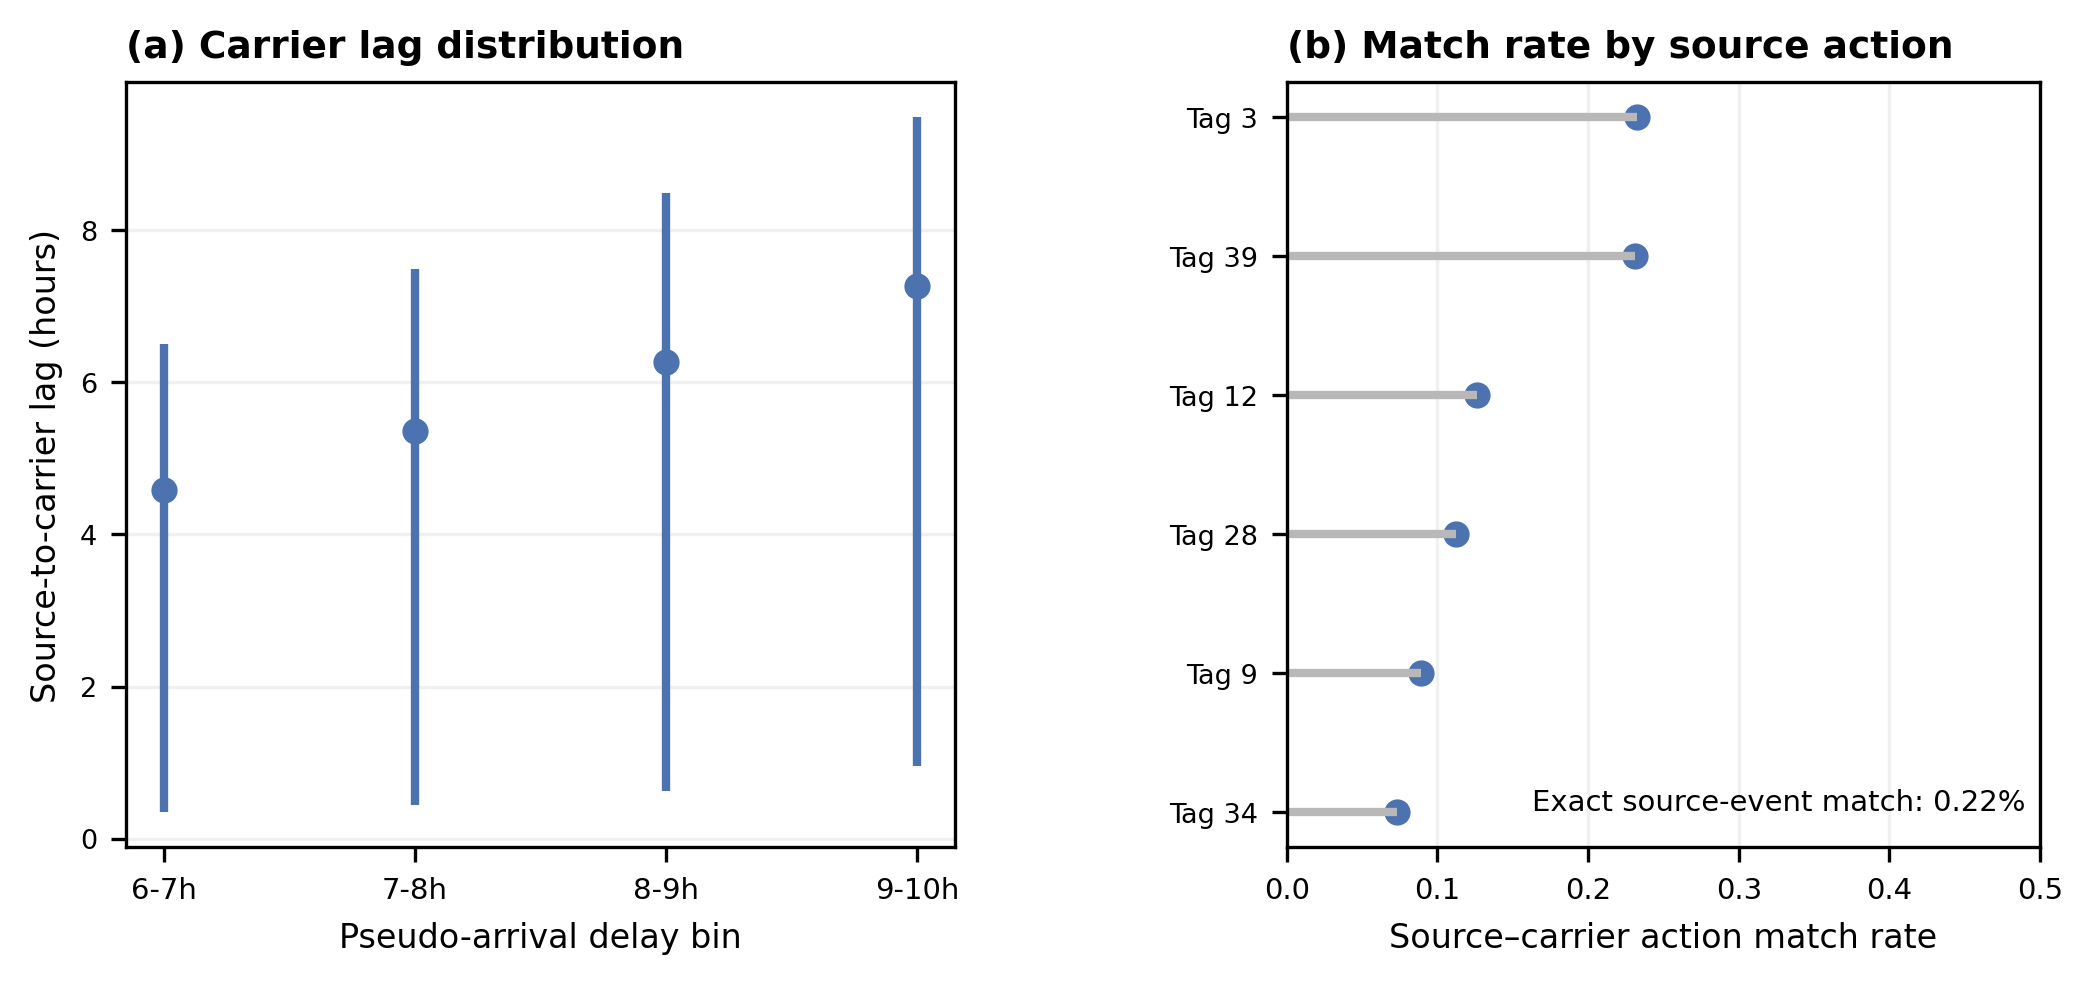

### exp4_controlled_route_audit

`exp4_controlled_route_audit/outputs/runs/full_20260726T140240Z_1be8996e/figures/png/fig_app_exp4_alignment_regret_association.png`

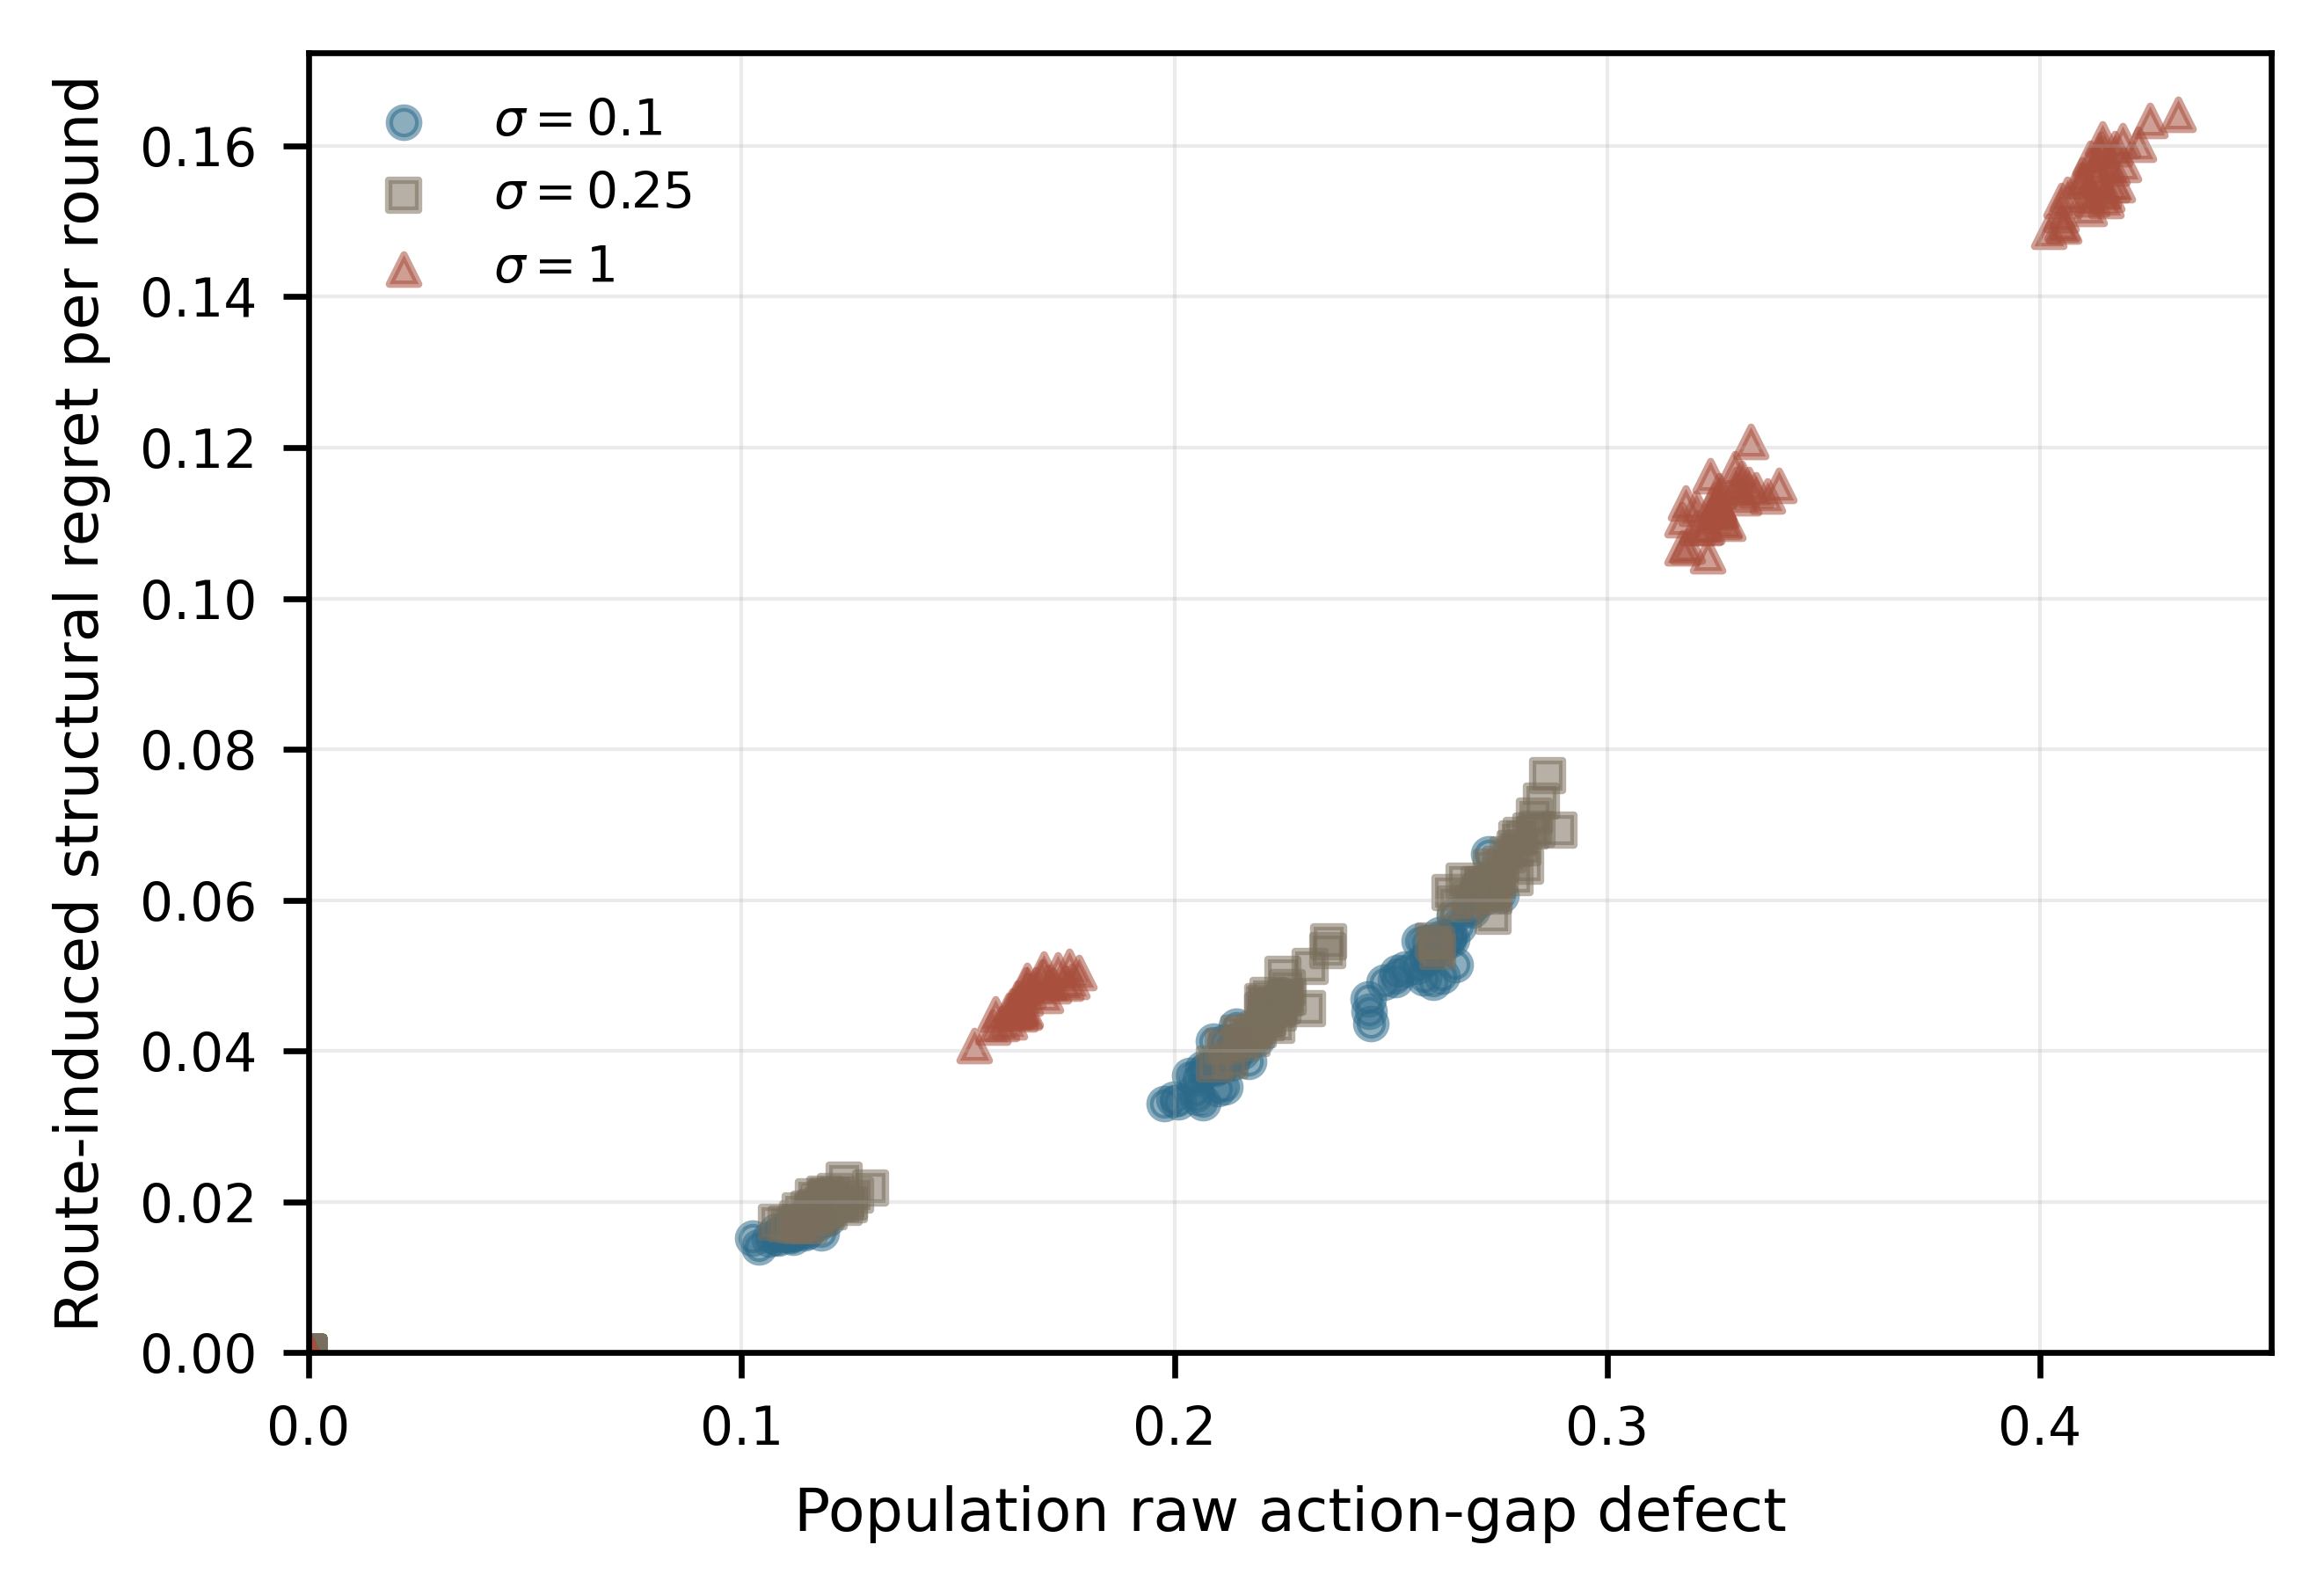

### toy

`toy/outputs/full/figures/toy_full_trajectories.png`

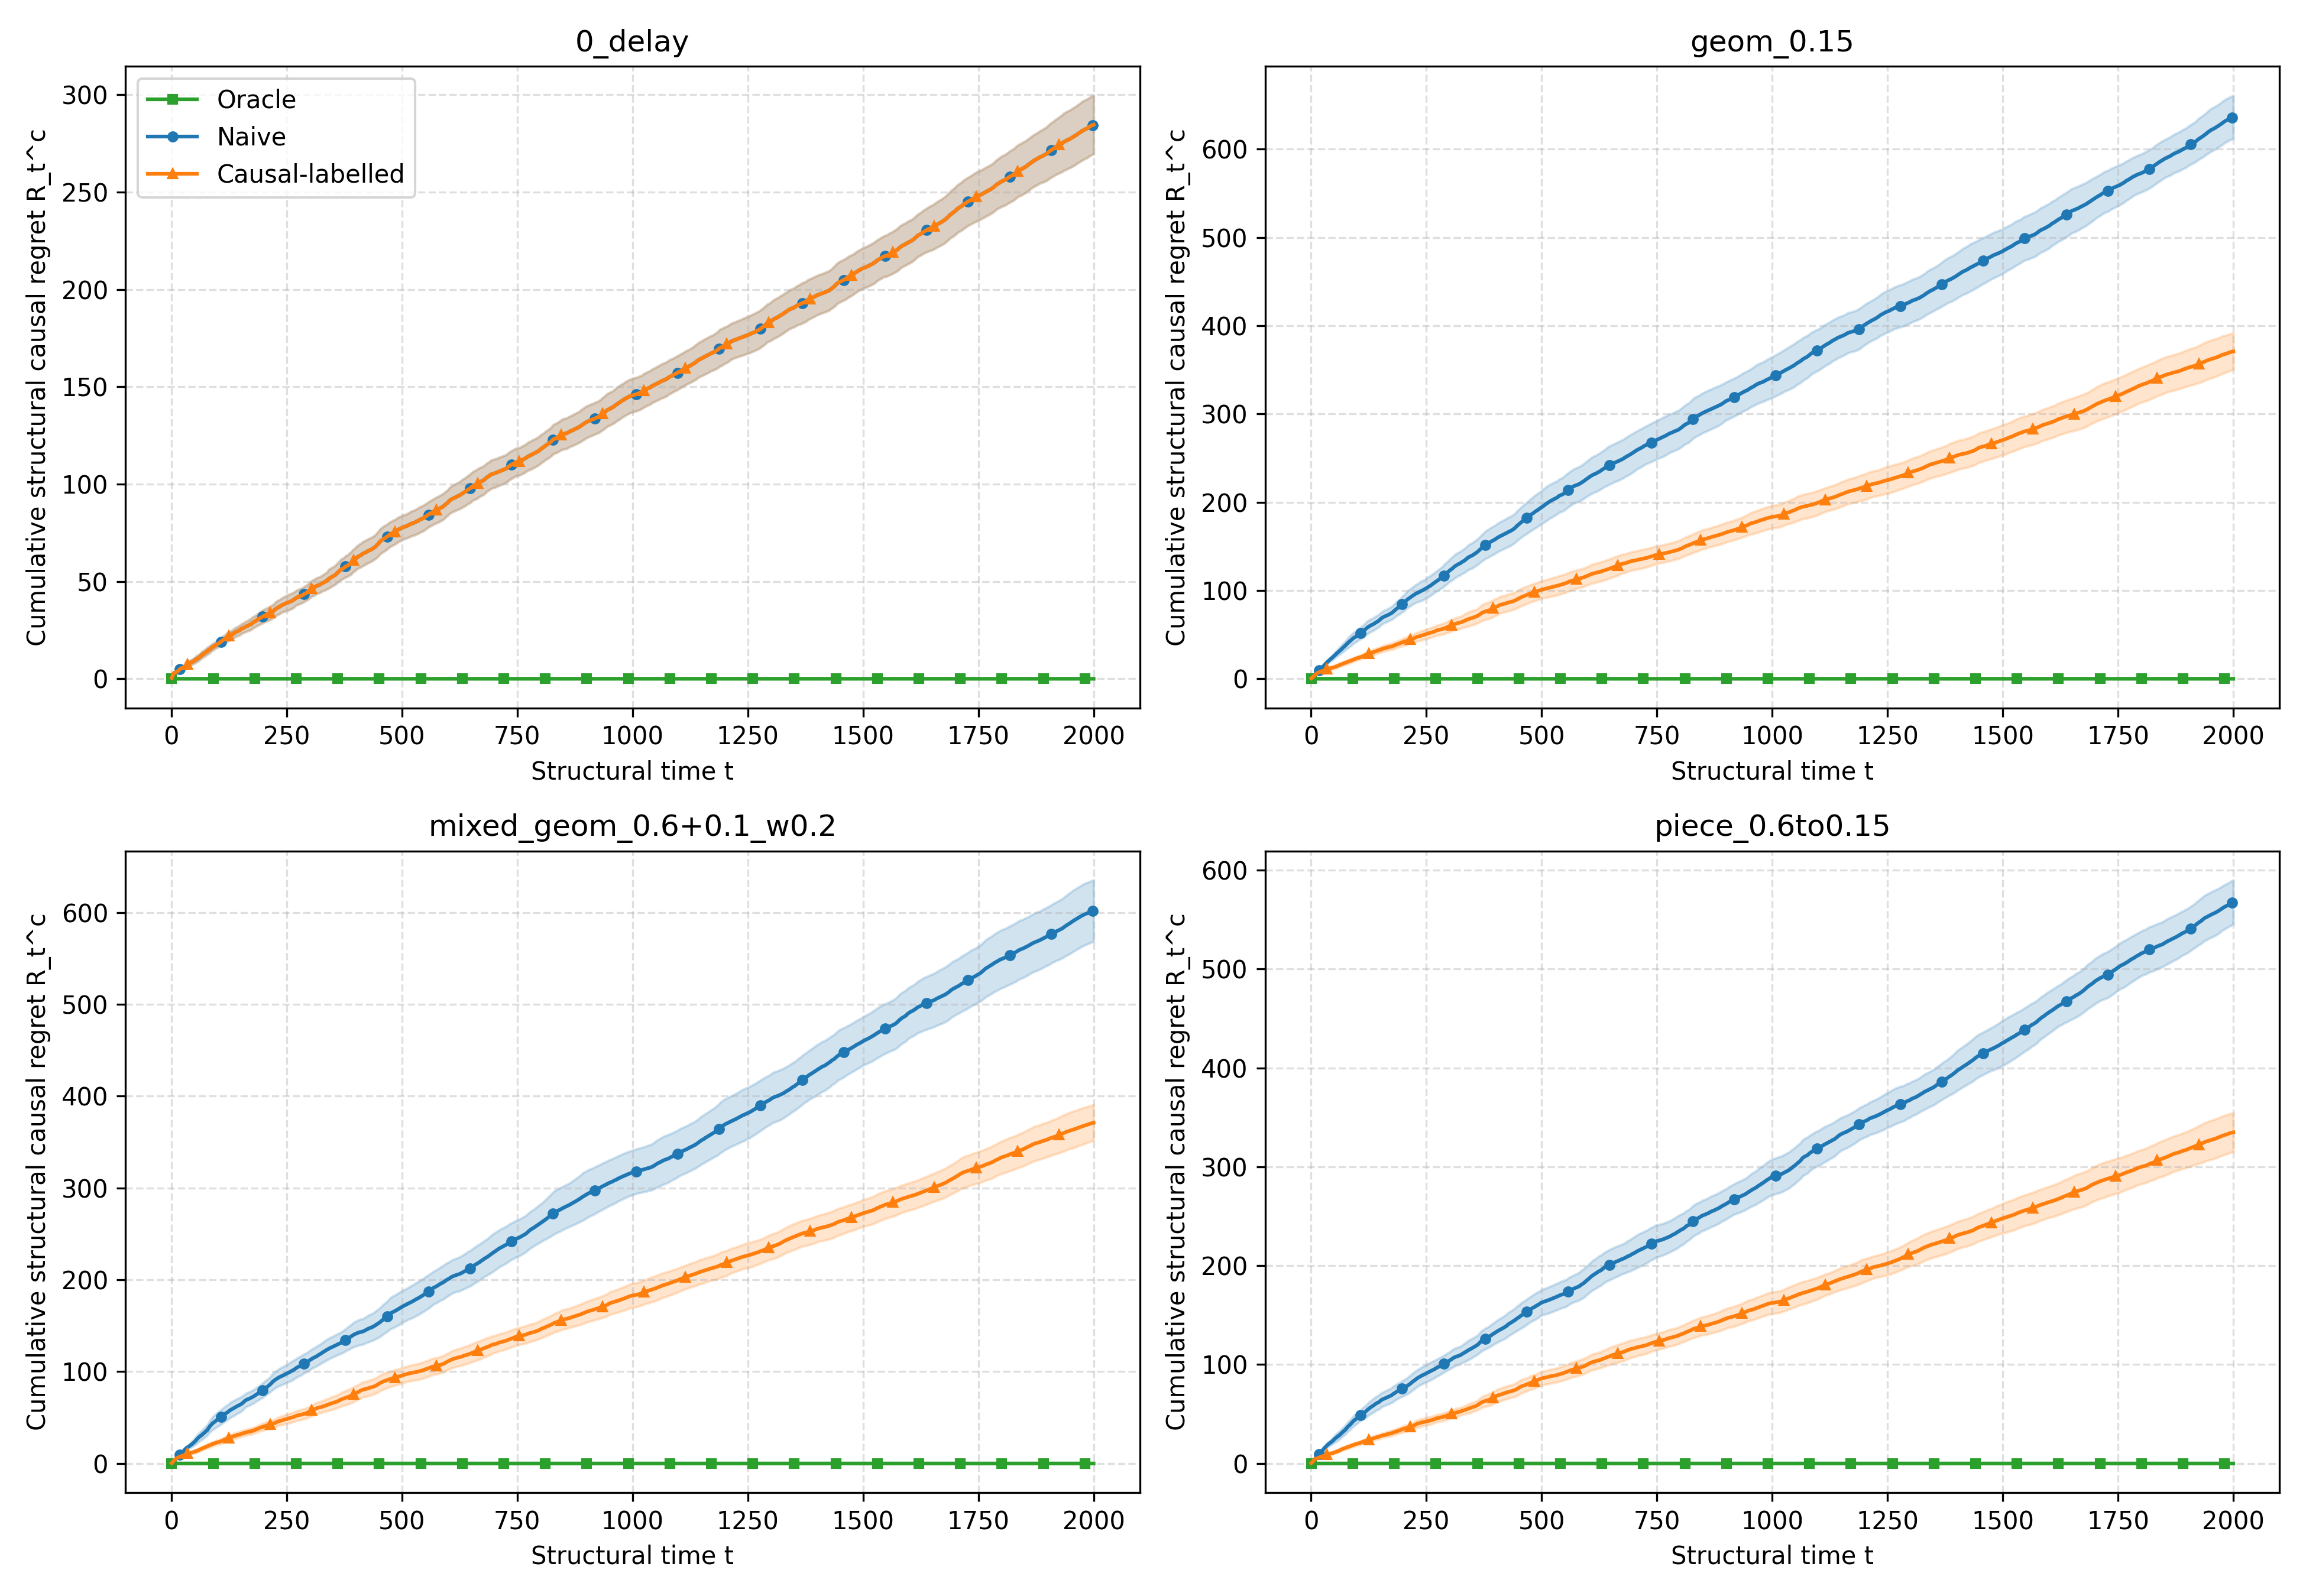

In [5]:

# Figure previews — reuses PROJECTS, ROOT, and prefer_figures from the overview cell above.

for name, _ in PROJECTS:
    base = ROOT / name
    figures = prefer_figures(base)
    display(Markdown(f'### {name}'))
    if figures:
        chosen = figures[0]
        display(Markdown(f'`{chosen.relative_to(ROOT).as_posix()}`'))
        display(Image(filename=str(chosen)))
    else:
        display(Markdown('*No PNG figure found in outputs.*'))


In [6]:

# Per-project output manifest — reuses PROJECTS and ROOT from the overview cell above.

for name, _ in PROJECTS:
    base = ROOT / name
    display(Markdown(f'### {name}'))
    summary = {
        'README': (base / 'README.md').exists(),
        'outputs/': (base / 'outputs').exists(),
        'tables (csv)': len(list(base.glob('outputs/**/tables/*.csv'))),
        'figures (png)': len(list(base.glob('outputs/**/figures/**/*.png'))),
    }
    display(pd.DataFrame([summary]))

display(Markdown('*Root overview reads existing files only and performs no recomputation.*'))


### exp1_alignment_transfer

,README,outputs/,tables (csv),figures (png)
0,True,True,3,11


### exp2_real_delayed_conversion_logs

,README,outputs/,tables (csv),figures (png)
0,True,True,9,9


### exp3_sequential_recommendation_delayed_feedback

...

### exp4_controlled_route_audit

,README,outputs/,tables (csv),figures (png)
0,True,True,14,12


### toy

,README,outputs/,tables (csv),figures (png)
0,True,True,0,4


*Root overview reads existing files only and performs no recomputation.*